In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set plotting style
sns.set(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_path = "/content/drive/MyDrive/Dataset/cardiovascular_risk_dataset.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully.
Shape of dataset: (5500, 17)


,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


In [6]:
if "Patient_ID" in df.columns:
    df = df.drop(columns=["Patient_ID"])

print("Updated Shape:", df.shape)

Updated Shape: (5500, 16)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               5500 non-null   int64  
 1   bmi                               5500 non-null   float64
 2   systolic_bp                       5500 non-null   int64  
 3   diastolic_bp                      5500 non-null   int64  
 4   cholesterol_mg_dl                 5500 non-null   int64  
 5   resting_heart_rate                5500 non-null   int64  
 6   smoking_status                    5500 non-null   object 
 7   daily_steps                       5500 non-null   int64  
 8   stress_level                      5500 non-null   int64  
 9   physical_activity_hours_per_week  5500 non-null   float64
 10  sleep_hours                       5500 non-null   float64
 11  family_history_heart_disease      5500 non-null   object 
 12  diet_q

In [7]:
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
age                                 0
bmi                                 0
systolic_bp                         0
diastolic_bp                        0
cholesterol_mg_dl                   0
resting_heart_rate                  0
smoking_status                      0
daily_steps                         0
stress_level                        0
physical_activity_hours_per_week    0
sleep_hours                         0
family_history_heart_disease        0
diet_quality_score                  0
alcohol_units_per_week              0
heart_disease_risk_score            0
risk_category                       0
dtype: int64


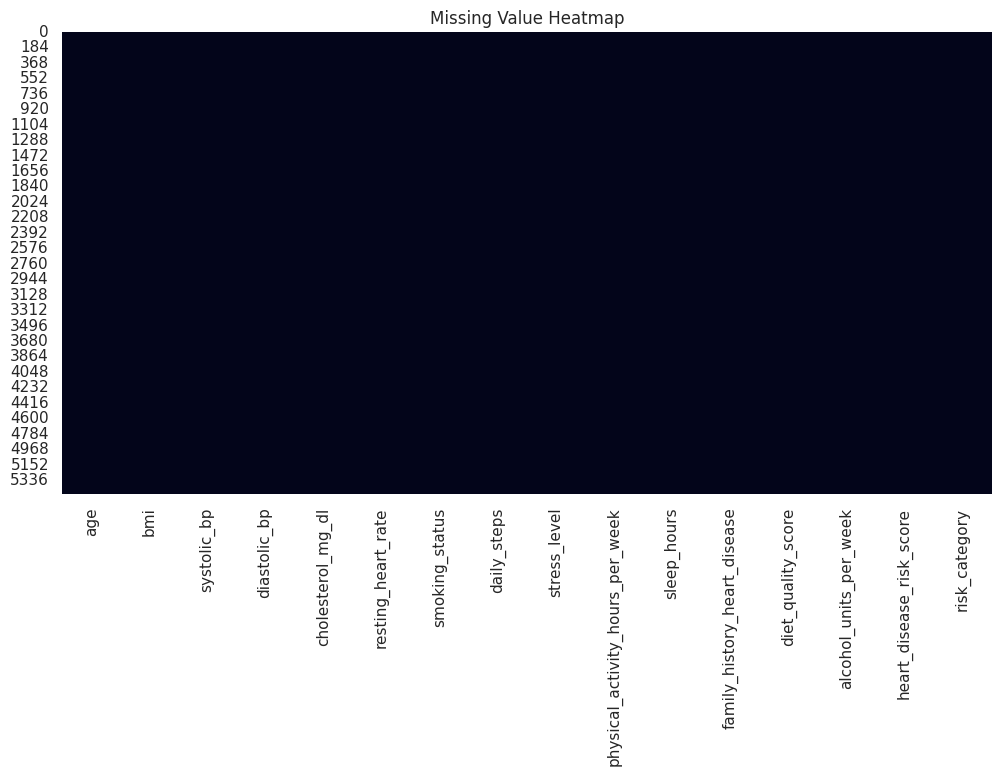

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
print(df["risk_category"].value_counts())
print(df["risk_category"].value_counts(normalize=True))

risk_category
Medium    2244
Low       1838
High      1418
Name: count, dtype: int64
risk_category
Medium    0.408000
Low       0.334182
High      0.257818
Name: proportion, dtype: float64


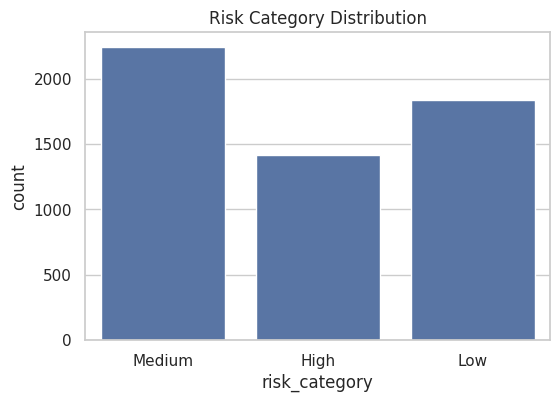

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="risk_category", data=df)
plt.title("Risk Category Distribution")
plt.show()

In [12]:
df["risk_category"] = df["risk_category"].map({
    "Low":0,
    "Medium":1,
    "High":2
})

In [13]:
df.describe()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455,0.923636
std,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026,0.765686
min,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000
25%,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000,0.000000
50%,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000,1.000000
75%,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000,2.000000
max,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000,2.000000


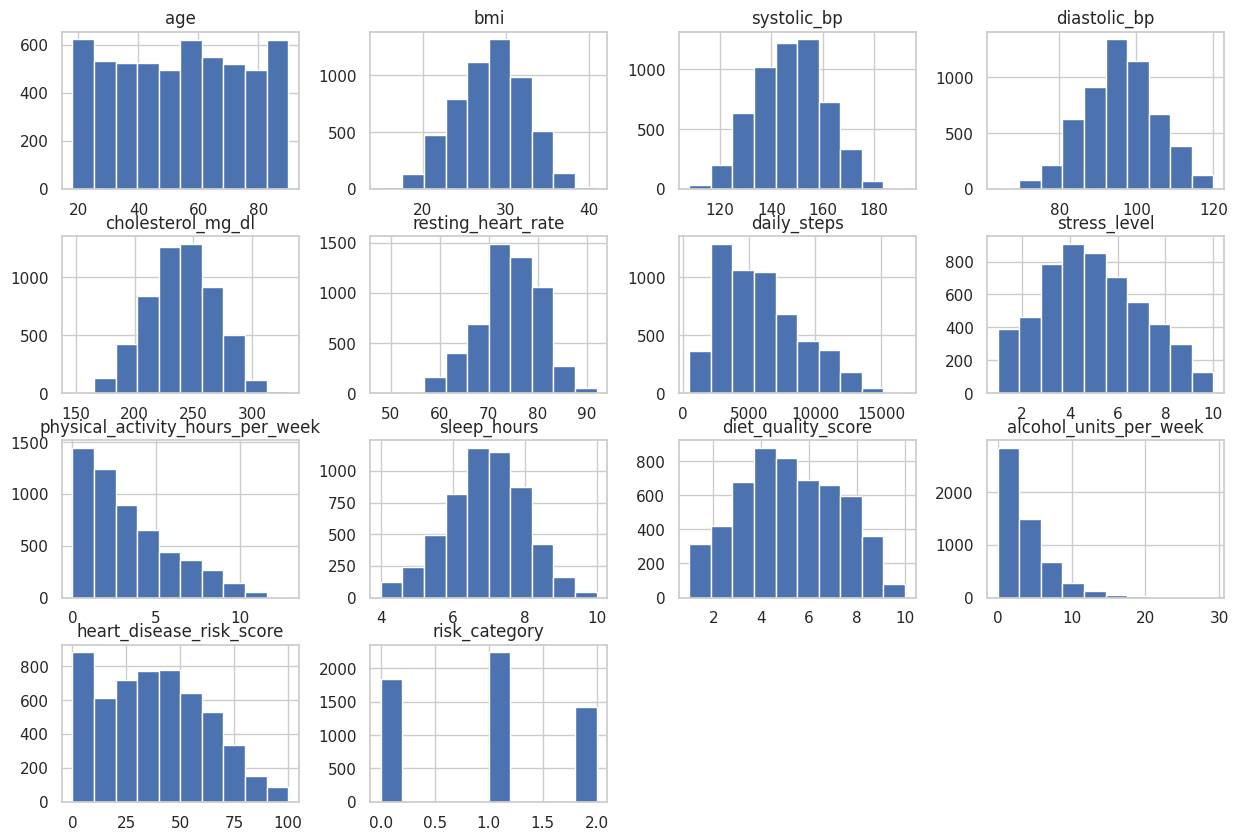

In [14]:
df.hist(figsize=(15,10))
plt.show()

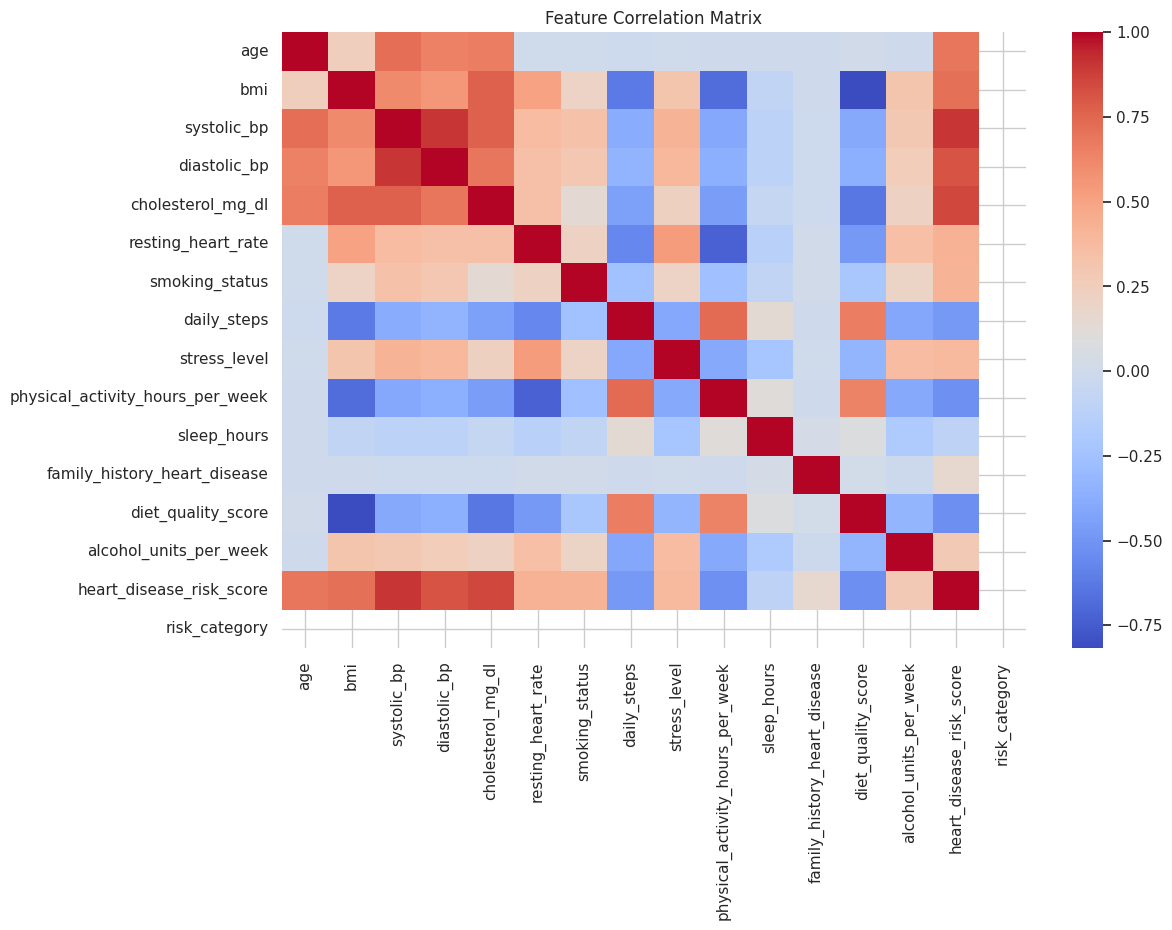

In [15]:
# Create a copy for correlation analysis
df_corr = df.copy()

# Encode categorical features
df_corr["smoking_status"] = df_corr["smoking_status"].map({
    "Never": 0,
    "Former": 1,
    "Current": 2
})

df_corr["family_history_heart_disease"] = df_corr["family_history_heart_disease"].map({
    "No": 0,
    "Yes": 1
})

# If risk_category is still text, encode it
df_corr["risk_category"] = df_corr["risk_category"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# Compute correlation matrix
corr = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
print(corr["risk_category"].sort_values(ascending=False))

age                                NaN
bmi                                NaN
systolic_bp                        NaN
diastolic_bp                       NaN
cholesterol_mg_dl                  NaN
resting_heart_rate                 NaN
smoking_status                     NaN
daily_steps                        NaN
stress_level                       NaN
physical_activity_hours_per_week   NaN
sleep_hours                        NaN
family_history_heart_disease       NaN
diet_quality_score                 NaN
alcohol_units_per_week             NaN
heart_disease_risk_score           NaN
risk_category                      NaN
Name: risk_category, dtype: float64


In [20]:
target_corr = corr["risk_category"].sort_values(ascending=False)

print(target_corr)

age                                NaN
bmi                                NaN
systolic_bp                        NaN
diastolic_bp                       NaN
cholesterol_mg_dl                  NaN
resting_heart_rate                 NaN
smoking_status                     NaN
daily_steps                        NaN
stress_level                       NaN
physical_activity_hours_per_week   NaN
sleep_hours                        NaN
family_history_heart_disease       NaN
diet_quality_score                 NaN
alcohol_units_per_week             NaN
heart_disease_risk_score           NaN
risk_category                      NaN
Name: risk_category, dtype: float64


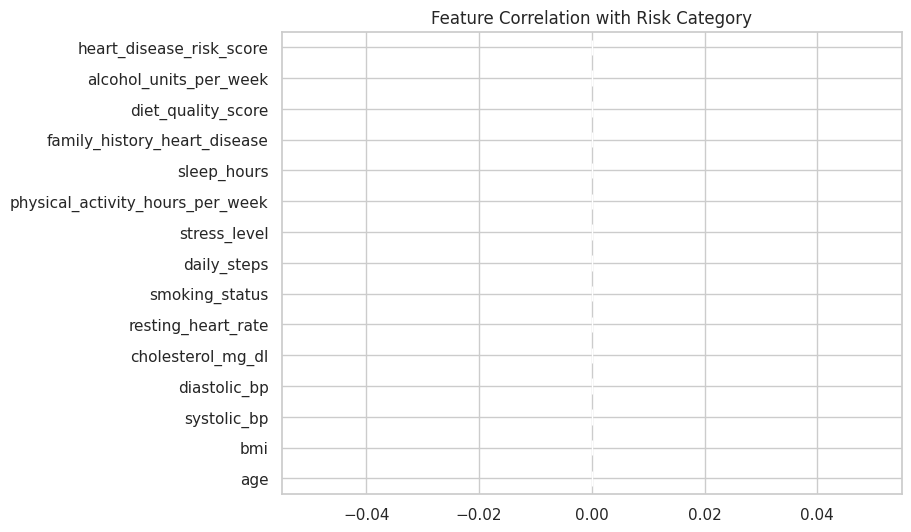

In [21]:
target_corr.drop("risk_category").plot(kind="barh", figsize=(8,6))
plt.title("Feature Correlation with Risk Category")
plt.show()

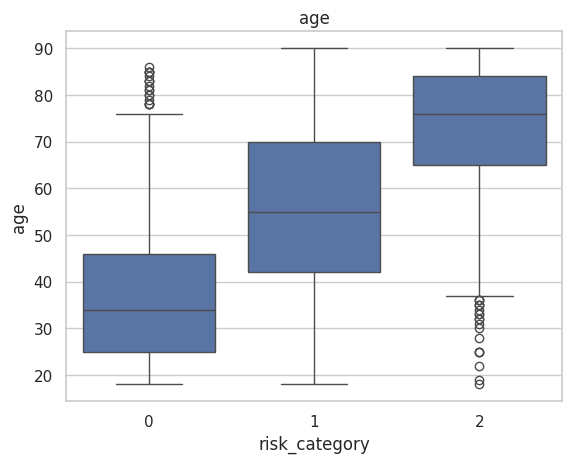

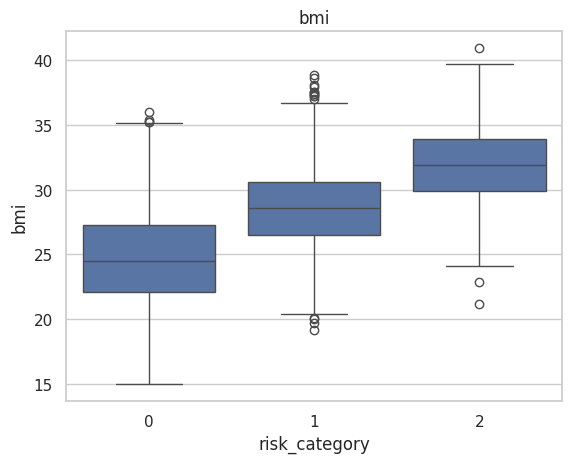

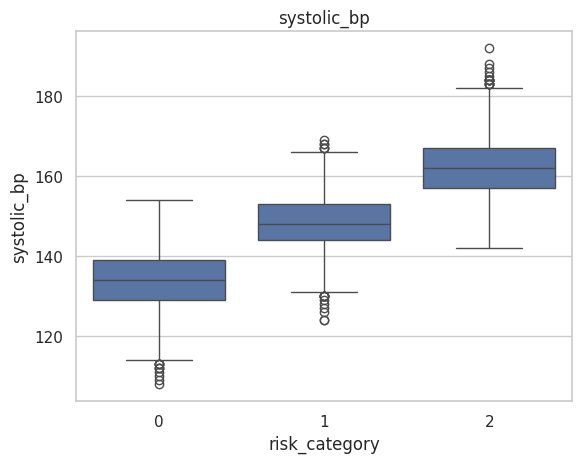

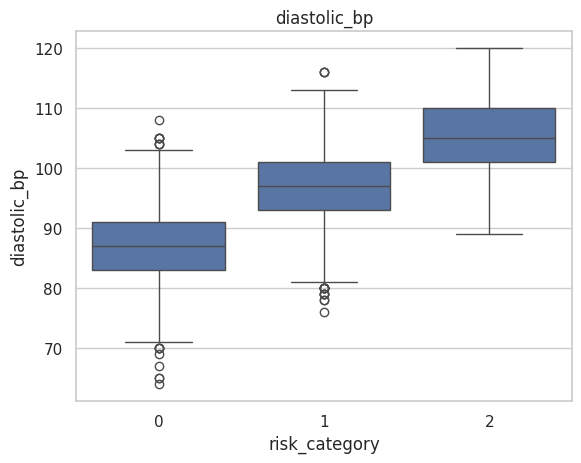

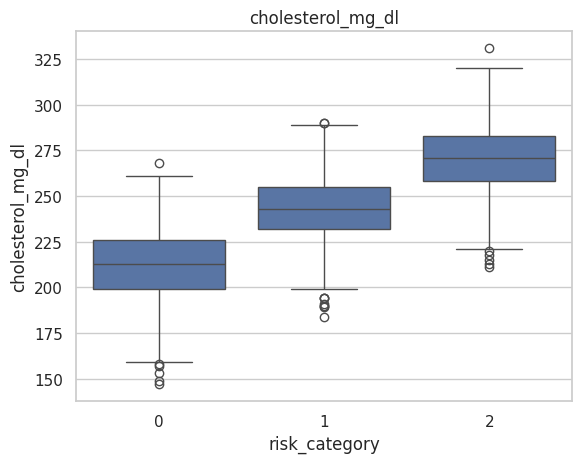

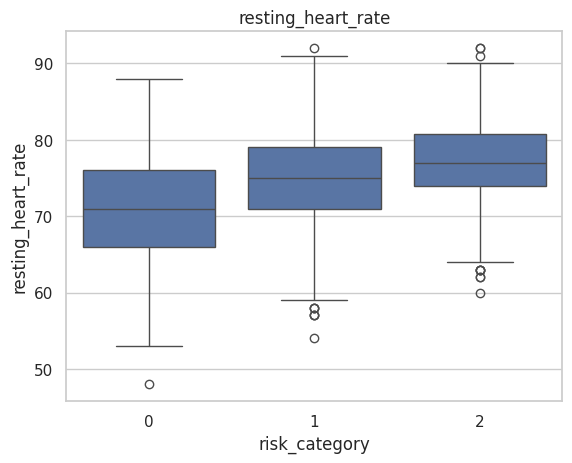

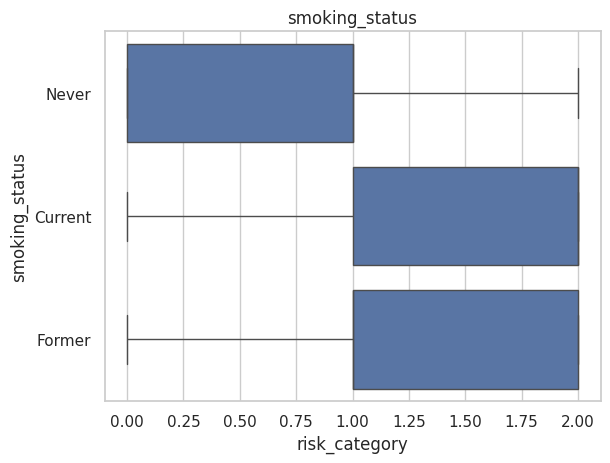

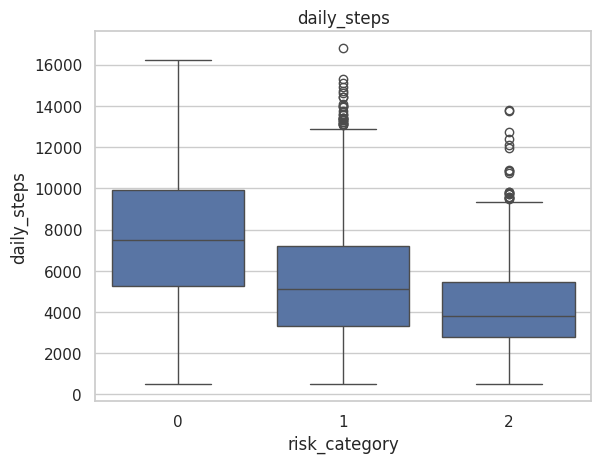

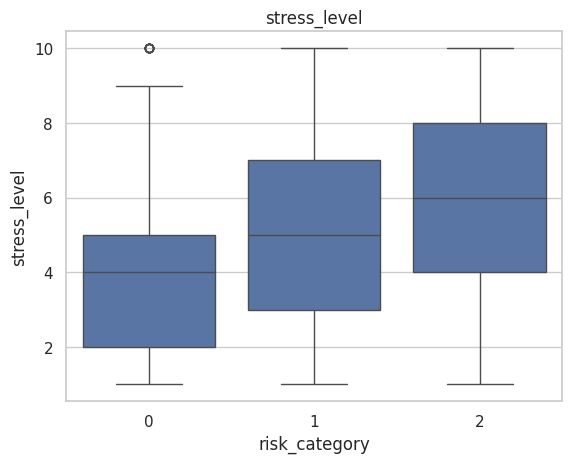

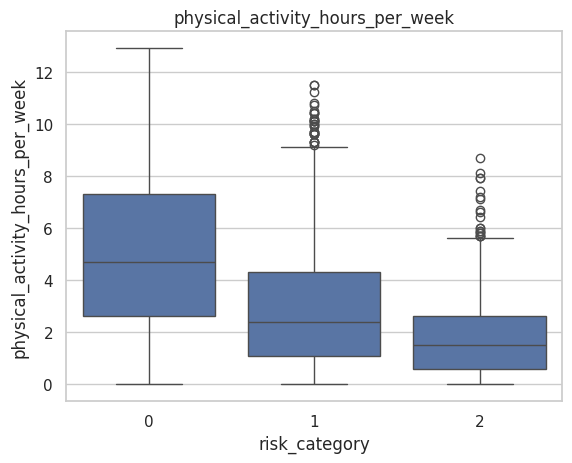

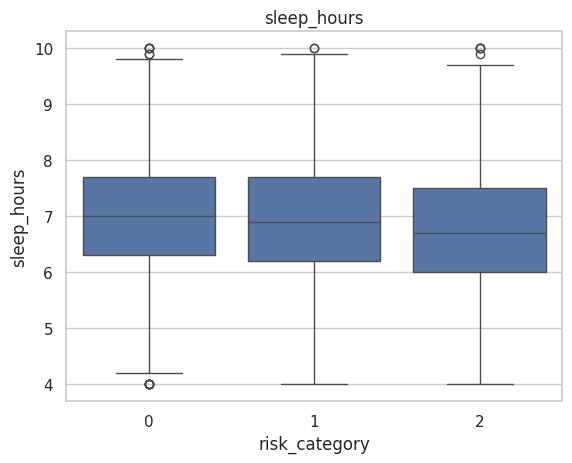

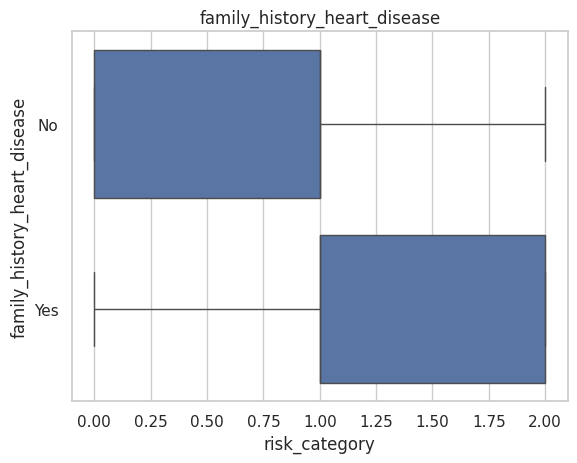

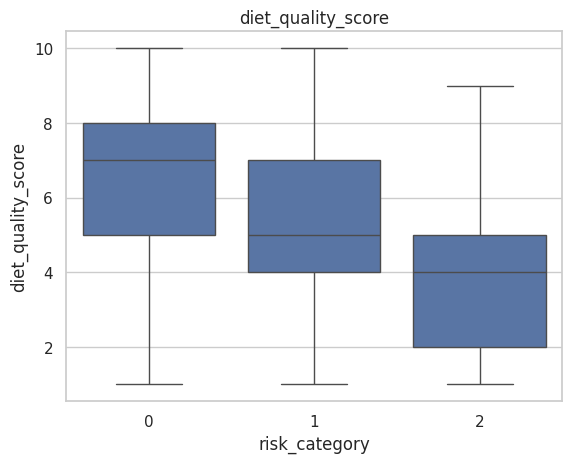

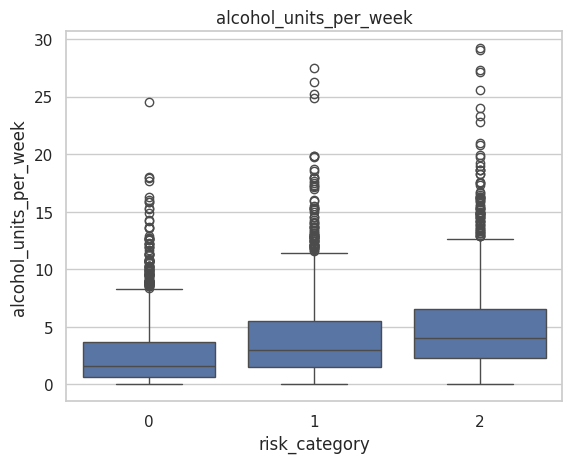

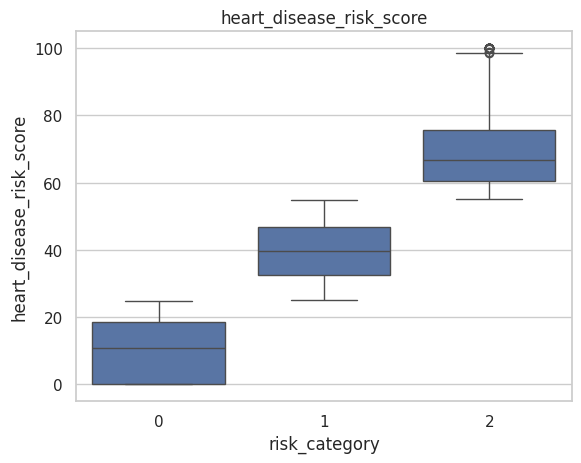

In [22]:
for col in df.columns:
    if col != "risk_category":
        sns.boxplot(x="risk_category", y=col, data=df)
        plt.title(col)
        plt.show()

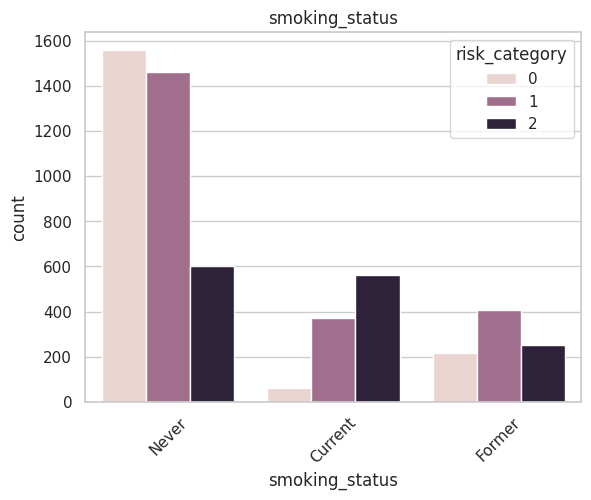

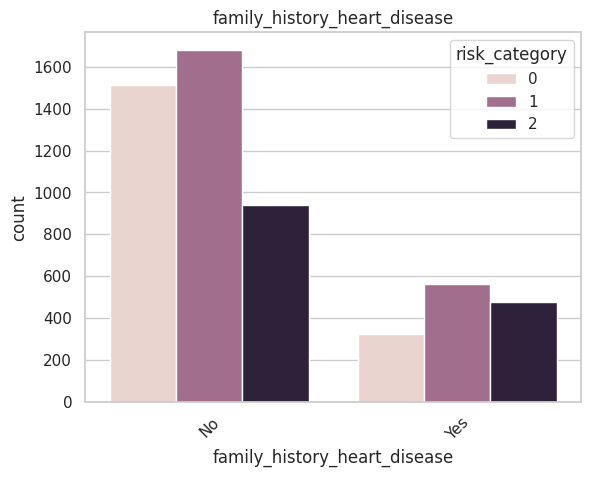

In [23]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    sns.countplot(x=col, hue="risk_category", data=df)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

## Feature Leakage Detection and Removal

During the correlation analysis, it was observed that the feature
`heart_disease_risk_score` had an extremely high correlation with the
target variable `risk_category`.

This occurs because the risk category is derived from the risk score.
Including this feature would lead to data leakage, allowing the model
to indirectly access the target variable.

To ensure a fair and realistic machine learning model, the
`heart_disease_risk_score` feature is removed before model training.

In [24]:
# ===============================
# Feature Leakage Detection
# ===============================

print("Correlation with target before removing leakage feature:")
print(target_corr)

# ===============================
# Remove Leakage Feature
# ===============================

df = df.drop(columns=["heart_disease_risk_score"])

print("\nUpdated Dataset Shape:", df.shape)

print("\nRemaining Columns:")
print(df.columns)

Correlation with target before removing leakage feature:
age                                NaN
bmi                                NaN
systolic_bp                        NaN
diastolic_bp                       NaN
cholesterol_mg_dl                  NaN
resting_heart_rate                 NaN
smoking_status                     NaN
daily_steps                        NaN
stress_level                       NaN
physical_activity_hours_per_week   NaN
sleep_hours                        NaN
family_history_heart_disease       NaN
diet_quality_score                 NaN
alcohol_units_per_week             NaN
heart_disease_risk_score           NaN
risk_category                      NaN
Name: risk_category, dtype: float64

Updated Dataset Shape: (5500, 15)

Remaining Columns:
Index(['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_mg_dl',
       'resting_heart_rate', 'smoking_status', 'daily_steps', 'stress_level',
       'physical_activity_hours_per_week', 'sleep_hours',
       'family_hist

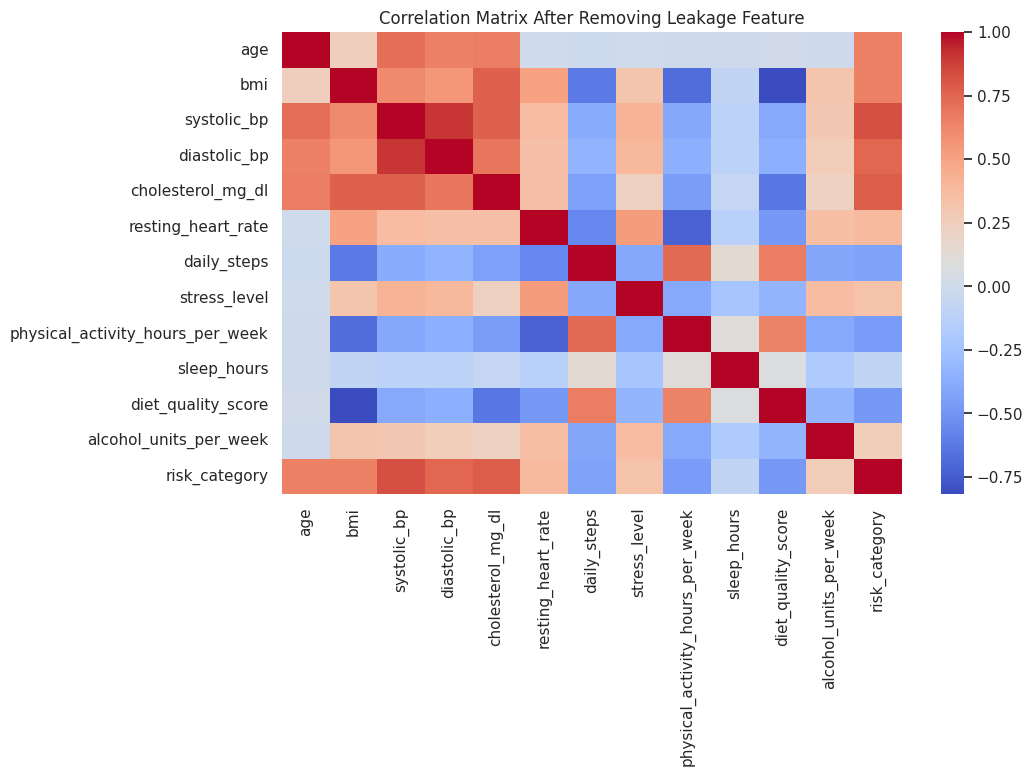

In [25]:
# Verify dataset after removing leakage feature

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix After Removing Leakage Feature")
plt.show()

## Dataset Validation Conclusion

The dataset was validated through several data quality checks before
developing machine learning models.

The validation process included:

• Dataset size verification
• Missing value detection
• Duplicate record analysis
• Feature distribution analysis
• Correlation analysis
• Feature leakage detection

The dataset contains 5500 patient records and multiple physiological
and lifestyle features relevant to cardiovascular health.

Class distribution of the target variable (risk_category) was found
to be reasonably balanced across three classes:

Low Risk    – 33.4%
Medium Risk – 40.8%
High Risk   – 25.7%

Correlation analysis revealed meaningful relationships between
clinical variables and heart disease risk, including:

• Blood pressure
• Cholesterol levels
• Age
• Body Mass Index
• Smoking status
• Stress levels

Lifestyle factors such as daily steps, diet quality, and physical
activity showed negative correlations with heart disease risk, which
aligns with established medical knowledge.

During validation, the feature `heart_disease_risk_score` was found to
have extremely high correlation with the target variable because the
risk category is derived from this score. Including this feature would
introduce data leakage.

Therefore, the `heart_disease_risk_score` column was removed before
model development to ensure that the machine learning models learn
from genuine clinical and lifestyle predictors.

After validation and preprocessing, the dataset was deemed suitable
for developing machine learning models to predict cardiovascular risk.